# Неделя 4. VSX-разметка, объединение и разбор датасета

На этой неделе собираем единый набор с VSX и разбираем его структуру и качество.


## План занятия

1. Импорт и проверка входных файлов.
2. Получение VSX (два режима).
3. Объединение `base + VSX`.
4. Обзор датасета и его особенности
5. Индекс по координатам: RAJ2000 и DEJ2000
6. Предобработка и структура данных
7. Просмотр описательных статистик и основы стилизации таблиц
8. Чистим датасет от невалидных наблюдений
9. Что ещё можно вытянуть из данных?
10. Сохранение результата недели.


In [28]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('.')
BASE_PATH = DATA_DIR / 'seminar1_base_dataset.csv'

VSX_CACHE_PATH = DATA_DIR / 'data' / 'vsx_xmatch_cache.csv'
VSX_ALL_PATH = DATA_DIR / 'data' / 'vsx_all.csv'

MERGED_RAW_PATH = DATA_DIR / 'w4_merged_with_vsx_raw.csv'
OUTPUT_PATH = DATA_DIR / 'w4_labeled_dataset.csv'

DATA_DIR.mkdir(parents=True, exist_ok=True)
VSX_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

Проверяем, что данные недели 3 доступны.


In [29]:
if not BASE_PATH.exists():
    raise FileNotFoundError('Не найден входной файл: ' + str(BASE_PATH))

print('Входной файл:', BASE_PATH)
print('VSX cache   :', VSX_CACHE_PATH)
print('VSX all     :', VSX_ALL_PATH)


Входной файл: seminar1_base_dataset.csv
VSX cache   : data/vsx_xmatch_cache.csv
VSX all     : data/vsx_all.csv


Загружаем базовую таблицу. Это исходная точка перед добавлением VSX.


In [30]:
base = pd.read_csv(BASE_PATH)

print('base shape:', base.shape)
display(base.head(3))


base shape: (847823, 28)


,RAJ2000,DEJ2000,nobs,Vmag,e_Vmag,Bmag,e_Bmag,gpmag,e_gpmag,rpmag,...,imputed_fuv,imputed_nuv,imputed_J,imputed_H,imputed_K,has_galex,has_2mass,match_sep_arcsec,match_phot_chi2,quality_realistic
0,46.236715,5.967756,4.0,13.173,0.021,13.863,0.035,13.455,0.024,12.991,...,1,0,1,1,1,1,0,NaN,NaN,1
1,46.372358,6.001498,4.0,15.271,0.014,16.236,0.054,15.708,0.022,14.923,...,0,0,1,1,1,1,0,NaN,NaN,1
2,46.295090,6.012614,5.0,12.766,0.015,13.421,0.043,13.047,0.022,12.566,...,1,0,1,1,1,1,0,NaN,NaN,1


## 1. Получение VSX: online и offline

два режима:

- `RUN_VSX_XMATCH=False` — работаем с локальным кэшем,
- `RUN_VSX_XMATCH=True` — реальная выгрузка через batch XMatch.


In [ ]:
RUN_VSX_XMATCH = False
RESUME_DOWNLOAD = True

XMATCH_RADIUS_ARCSEC = 2.0
BATCH_SIZE = 50000
QUERY_LIMIT = None
START_FROM = 0
SAMPLE_FRAC = None      # например 0.01 для теста
SAMPLE_RANDOM_STATE = 42

MAX_RETRIES = 3
RETRY_SLEEP_SEC = 3.0

VSX_CATALOG_ID = 'vizier:B/vsx/vsx'


def _norm_key(ra, dec, nd=7):
    return (round(float(ra), nd), round(float(dec), nd))


def _pick_col(df, candidates):
    cmap = {c.lower(): c for c in df.columns}
    for cand in candidates:
        c = cmap.get(cand.lower())
        if c is not None:
            return c
    return None


def _to_float(s):
    return pd.to_numeric(s, errors='coerce')


def _dedup_all_df(df):
    if df.empty:
        return df
    dedup_cols = [c for c in ['query_ra', 'query_dec', 'vsx_sep_arcsec', 'vsx_name'] if c in df.columns]
    return df.drop_duplicates(dedup_cols, keep='last') if dedup_cols else df


def run_xmatch_batch(batch_df, radius_arcsec):
    from astroquery.xmatch import XMatch
    from astropy.table import Table
    import astropy.units as u

    query = batch_df[['RAJ2000', 'DEJ2000']].copy().rename(columns={'RAJ2000': 'ra', 'DEJ2000': 'dec'})

    out = pd.DataFrame({
        'query_ra': query['ra'].astype(float),
        'query_dec': query['dec'].astype(float),
        'present': 0,
        'type': '',
        'period': np.nan,
        'min_mag': np.nan,
        'max_mag': np.nan,
        'name': '',
        'vsx_sep_arcsec': np.nan,
    })

    tbl = Table.from_pandas(query)

    xm = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            xm = XMatch.query(
                cat1=tbl,
                cat2=VSX_CATALOG_ID,
                max_distance=radius_arcsec * u.arcsec,
                colRA1='ra',
                colDec1='dec',
            )
            break
        except Exception as exc:
            last_error = exc
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_SLEEP_SEC * attempt)

    if xm is None:
        print(f'XMatch batch error: {last_error}')
        return out, pd.DataFrame()

    xm_df = xm.to_pandas()
    if xm_df.empty:
        return out, xm_df

    ra_col = _pick_col(xm_df, ['ra', 'RA', '_RAJ2000'])
    dec_col = _pick_col(xm_df, ['dec', 'DEC', '_DEJ2000'])
    dist_col = _pick_col(xm_df, ['angDist', '_r'])
    type_col = _pick_col(xm_df, ['Type'])
    period_col = _pick_col(xm_df, ['Period'])
    min_col = _pick_col(xm_df, ['min'])
    max_col = _pick_col(xm_df, ['max'])
    name_col = _pick_col(xm_df, ['Name'])

    if ra_col is None or dec_col is None:
        return out, xm_df

    raw_all = xm_df.copy()
    raw_all['query_ra'] = _to_float(raw_all[ra_col])
    raw_all['query_dec'] = _to_float(raw_all[dec_col])
    raw_all['vsx_sep_arcsec'] = _to_float(raw_all[dist_col]) if dist_col else np.nan
    raw_all['vsx_name'] = raw_all[name_col].fillna('').astype(str) if name_col else ''

    best = raw_all.sort_values('vsx_sep_arcsec', na_position='last')
    best = best.drop_duplicates(['query_ra', 'query_dec'], keep='first')

    keep = ['query_ra', 'query_dec', 'vsx_sep_arcsec']
    if type_col:
        best['type'] = best[type_col].fillna('').astype(str)
        keep.append('type')
    if period_col:
        best['period'] = _to_float(best[period_col])
        keep.append('period')
    if min_col:
        best['min_mag'] = _to_float(best[min_col])
        keep.append('min_mag')
    if max_col:
        best['max_mag'] = _to_float(best[max_col])
        keep.append('max_mag')
    if name_col:
        best['name'] = best[name_col].fillna('').astype(str)
        keep.append('name')

    best['present'] = 1
    keep.append('present')

    out = out.merge(best[keep], on=['query_ra', 'query_dec'], how='left', suffixes=('', '_m'))

    for col in ['present', 'type', 'period', 'min_mag', 'max_mag', 'name', 'vsx_sep_arcsec']:
        m = f'{col}_m'
        if m in out.columns:
            if col == 'present':
                out[col] = out[m].fillna(0).astype(int)
            elif col in ['type', 'name']:
                out[col] = out[m].fillna('')
            else:
                out[col] = out[m].combine_first(out[col])
            out = out.drop(columns=[m])

    return out, raw_all

In [ ]:
coords = base[['RAJ2000', 'DEJ2000']].drop_duplicates().copy()

if START_FROM:
    coords = coords.iloc[int(START_FROM):].copy()
if QUERY_LIMIT is not None:
    coords = coords.head(int(QUERY_LIMIT)).copy()
if SAMPLE_FRAC is not None:
    if not (0 < float(SAMPLE_FRAC) <= 1):
        raise ValueError('SAMPLE_FRAC должен быть в диапазоне (0, 1].')
    n_before = len(coords)
    coords = coords.sample(frac=float(SAMPLE_FRAC), random_state=SAMPLE_RANDOM_STATE).copy()
    print(f'Тестовый режим: {len(coords)} из {n_before} ({float(SAMPLE_FRAC):.1%}).')

if RUN_VSX_XMATCH:
    done_keys = set()
    if RESUME_DOWNLOAD and VSX_CACHE_PATH.exists():
        prev = pd.read_csv(VSX_CACHE_PATH)
        if {'query_ra', 'query_dec'}.issubset(prev.columns):
            done_keys = {_norm_key(r, d) for r, d in prev[['query_ra', 'query_dec']].itertuples(index=False, name=None)}

    key_series = coords.apply(lambda r: _norm_key(r['RAJ2000'], r['DEJ2000']), axis=1)
    coords_todo = coords.loc[~key_series.isin(done_keys)].copy()

    total = len(coords_todo)
    print('Всего координат к обработке:', total)

    chunks = []
    all_chunks = []
    for start in range(0, total, BATCH_SIZE):
        end = min(start + BATCH_SIZE, total)
        batch = coords_todo.iloc[start:end].copy()
        batch_out, batch_all = run_xmatch_batch(batch, XMATCH_RADIUS_ARCSEC)
        chunks.append(batch_out)
        if not batch_all.empty:
            all_chunks.append(batch_all)
        print(f'XMatch progress: {end}/{total}')

    new_rows = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

    if RESUME_DOWNLOAD and VSX_CACHE_PATH.exists() and len(new_rows):
        old = pd.read_csv(VSX_CACHE_PATH)
        compact_cache = pd.concat([old, new_rows], ignore_index=True)
    else:
        compact_cache = new_rows

    if len(compact_cache):
        compact_cache = compact_cache.drop_duplicates(['query_ra', 'query_dec'], keep='last')
        compact_cache.to_csv(VSX_CACHE_PATH, index=False)
        print('Компактный кэш сохранен:', VSX_CACHE_PATH, '| rows =', len(compact_cache))

    new_all = pd.concat(all_chunks, ignore_index=True) if all_chunks else pd.DataFrame()
    if RESUME_DOWNLOAD and VSX_ALL_PATH.exists() and len(new_all):
        old_all = pd.read_csv(VSX_ALL_PATH)
        full_all = pd.concat([old_all, new_all], ignore_index=True, sort=False)
    else:
        full_all = new_all

    full_all = _dedup_all_df(full_all)
    if len(full_all):
        full_all.to_csv(VSX_ALL_PATH, index=False)
        print('Полный ответ сохранен:', VSX_ALL_PATH, '| rows =', len(full_all))
else:
    print('RUN_VSX_XMATCH=False: online выгрузка пропущена.')

RUN_VSX_XMATCH=False: online выгрузка пропущена.


## 2. Читаем локальный VSX-кэш

Здесь продолжаем в любом случае: либо после online-выгрузки, либо сразу из готового файла.


In [ ]:
if not VSX_CACHE_PATH.exists():
    raise FileNotFoundError(
        'Не найден VSX кэш: ' + str(VSX_CACHE_PATH) + '\n'
        'Либо запусти online-выгрузку, либо положи локальный файл в data/.'
    )

vsx_raw = pd.read_csv(VSX_CACHE_PATH)

req_cols = ['query_ra', 'query_dec', 'present', 'type', 'period', 'min_mag', 'max_mag', 'name', 'vsx_sep_arcsec']
for c in req_cols:
    if c not in vsx_raw.columns:
        if c == 'present':
            vsx_raw[c] = 0
        elif c in ['type', 'name']:
            vsx_raw[c] = ''
        else:
            vsx_raw[c] = np.nan

vsx_raw['present'] = vsx_raw['present'].fillna(0).astype(int)
vsx_raw['query_ra'] = pd.to_numeric(vsx_raw['query_ra'], errors='coerce')
vsx_raw['query_dec'] = pd.to_numeric(vsx_raw['query_dec'], errors='coerce')

print('vsx_raw shape:', vsx_raw.shape)
display(vsx_raw.head(3))

vsx_raw shape: (845350, 9)


,query_ra,query_dec,present,type,period,min_mag,max_mag,name,vsx_sep_arcsec
0,46.236715,5.967756,0,NaN,NaN,NaN,NaN,NaN,NaN
1,46.372358,6.001498,0,NaN,NaN,NaN,NaN,NaN,NaN
2,46.295090,6.012614,0,NaN,NaN,NaN,NaN,NaN,NaN


Короткая проверка качества VSX-матча по расстоянию.


Доля найденных VSX объектов: 3.32%


,vsx_sep_arcsec
count,28068.000000
mean,0.389724
std,0.340379
min,0.000000
50%,0.284573
90%,0.831251
95%,1.119597
99%,1.701651
max,1.999536


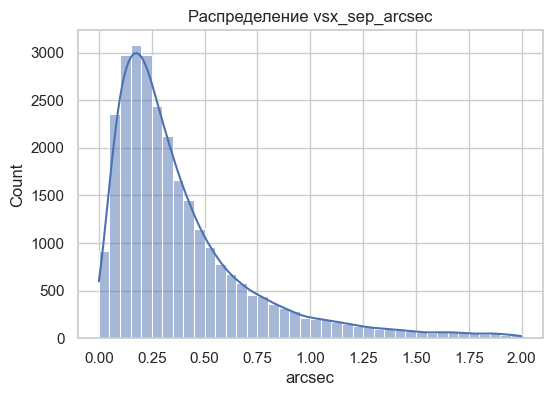

In [32]:
found_share = vsx_raw['present'].mean()
print(f'Доля найденных VSX объектов: {found_share:.2%}')

sep = vsx_raw.loc[vsx_raw['present'] == 1, 'vsx_sep_arcsec'].dropna()
if len(sep):
    display(sep.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame('vsx_sep_arcsec'))

    plt.figure(figsize=(6, 4))
    sns.histplot(sep, bins=40, kde=True)
    plt.title('Распределение vsx_sep_arcsec')
    plt.xlabel('arcsec')
    plt.show()


## 3. Объединение base + VSX

Сшиваем таблицы по координатному ключу (округление до 6 знаков),
затем формирую целевую переменную `target_variable`.


In [33]:
base2 = base.copy()
base2['ra_key'] = base2['RAJ2000'].round(6)
base2['dec_key'] = base2['DEJ2000'].round(6)

vsx = vsx_raw.copy()
vsx['ra_key'] = vsx['query_ra'].round(6)
vsx['dec_key'] = vsx['query_dec'].round(6)

merge_cols = ['ra_key', 'dec_key', 'present', 'type', 'period', 'min_mag', 'max_mag', 'name', 'vsx_sep_arcsec']
merged = base2.merge(vsx[merge_cols], on=['ra_key', 'dec_key'], how='left')

merged = merged.rename(columns={
    'present': 'vsx_present',
    'type': 'vsx_type',
    'period': 'vsx_period',
    'min_mag': 'vsx_min_mag',
    'max_mag': 'vsx_max_mag',
    'name': 'vsx_name',
})

merged['vsx_present'] = merged['vsx_present'].fillna(0).astype(int)
merged['vsx_type'] = merged['vsx_type'].fillna('')
merged['vsx_name'] = merged['vsx_name'].fillna('')

for c in ['vsx_period', 'vsx_min_mag', 'vsx_max_mag', 'vsx_sep_arcsec']:
    if c not in merged.columns:
        merged[c] = np.nan

merged['vsx_amplitude'] = merged['vsx_max_mag'] - merged['vsx_min_mag']
merged['target_variable'] = merged['vsx_present'].astype(int)

merged = merged.drop(columns=['ra_key', 'dec_key'])

print('merged shape:', merged.shape)
print('Положительный класс (target=1):', int(merged['target_variable'].sum()))


merged shape: (847823, 37)
Положительный класс (target=1): 28127


Переименовываем колонки с техническими суффиксами: `_filled` появлялся в процессе сборки (значение было заполнено импутацией), `imputed_*` — соответствующий флаг (1 = значение не измерено, а оценочное). В финальном датасете эти детали сборки не нужны в названии, поэтому даём чистые имена: `fuv_mag`, `nuv_mag`, `Jmag`, `Hmag`, `Kmag` — для значений; `fuv_flag`, `nuv_flag`, `J_flag`, `H_flag`, `K_flag` — для флагов.

In [34]:
# Переименовываем технические суффиксы: _filled → чистые имена, imputed_* → *_flag
rename_map = {
    'fuv_mag_filled': 'fuv_mag',
    'nuv_mag_filled': 'nuv_mag',
    'Jmag_filled':    'Jmag',
    'Hmag_filled':    'Hmag',
    'Kmag_filled':    'Kmag',
    'imputed_fuv':    'fuv_flag',
    'imputed_nuv':    'nuv_flag',
    'imputed_J':      'J_flag',
    'imputed_H':      'H_flag',
    'imputed_K':      'K_flag',
}

merged = merged.rename(columns={k: v for k, v in rename_map.items() if k in merged.columns})

print('Переименовано колонок:', sum(k in merged.columns or v in merged.columns for k, v in rename_map.items()))
print('Пример:', [c for c in merged.columns if any(x in c for x in ['fuv', 'nuv', 'Jmag', 'flag'])])

Переименовано колонок: 10
Пример: ['fuv_mag', 'nuv_mag', 'Jmag', 'fuv_flag', 'nuv_flag', 'J_flag', 'H_flag', 'K_flag']


Фиксируем сырой merged-файл, чтобы к нему можно было вернуться без повторного матчинга.


In [35]:
merged.to_csv(MERGED_RAW_PATH, index=False)
print('Saved:', MERGED_RAW_PATH)


Saved: w4_merged_with_vsx_raw.csv


Ниже уже анализируем объединенный набор (`merged`).


## Обзор датасета и его особенности

На этом занятии мы работаем с астрономическим датасетом, содержащим наблюдения почти **850 тысяч звёзд** — как переменных, так и непеременных. После объединения с каталогом VSX (Variable Star indeX) у нас появилась целевая переменная `target_variable`: 1 означает, что звезда идентифицирована как переменная, 0 — что нет.

Для каждого объекта представлены:
- **APASS-фотометрия** в пяти оптических диапазонах: `Vmag`, `Bmag`, `gpmag`, `rpmag`, `ipmag`;
- **Ошибки APASS**: `e_Vmag`, `e_Bmag`, `e_gpmag`, `e_rpmag`, `e_ipmag` — это ключевые признаки: они отражают разброс яркости между наблюдениями и напрямую связаны с переменностью;
- **UV-данные** (GALEX): `fuv_mag`, `nuv_mag`;
- **ИК-данные** (2MASS): `Jmag`, `Hmag`, `Kmag`;
- **Флаги измерения**: `fuv_flag`, `nuv_flag`, `J_flag`, `H_flag`, `K_flag` (1 = значение оценочное, не измеренное); `has_galex`, `has_2mass`;
- **VSX-атрибуты**: тип переменной, период, амплитуда, расстояние при матчинге.

Задача классификации здесь нетривиальна: переменные звёзды составляют около **3,3% выборки**, что означает сильный дисбаланс классов. Граница между переменными и непеременными объектами нечёткая — многие звёзды ведут себя «где-то посередине», и разделить их только по доступным признакам затруднительно. Это создаёт сложность как для моделей, так и для выбора метрик качества.

In [36]:
df = merged.copy()

print('shape:', df.shape)
print('columns:', len(df.columns))
display(df.head(3))

class_stat = df['target_variable'].value_counts().rename_axis('target_variable').to_frame('rows')
class_stat['fraction'] = class_stat['rows'] / len(df)
display(class_stat)


shape: (847823, 37)
columns: 37


,RAJ2000,DEJ2000,nobs,Vmag,e_Vmag,Bmag,e_Bmag,gpmag,e_gpmag,rpmag,...,quality_realistic,vsx_present,vsx_type,vsx_period,vsx_min_mag,vsx_max_mag,vsx_name,vsx_sep_arcsec,vsx_amplitude,target_variable
0,46.236715,5.967756,4.0,13.173,0.021,13.863,0.035,13.455,0.024,12.991,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
1,46.372358,6.001498,4.0,15.271,0.014,16.236,0.054,15.708,0.022,14.923,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
2,46.295090,6.012614,5.0,12.766,0.015,13.421,0.043,13.047,0.022,12.566,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0


,rows,fraction
target_variable,,
0,819696,0.966824
1,28127,0.033176


Разбиваем колонки на смысловые блоки, чтобы наглядно понимать структуру таблицы.


In [37]:
apass_mag_cols = [c for c in ['Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag'] if c in df.columns]
apass_err_cols = [c for c in ['e_Vmag', 'e_Bmag', 'e_gpmag', 'e_rpmag', 'e_ipmag'] if c in df.columns]
uv_ir_cols = [c for c in ['fuv_mag', 'nuv_mag', 'Jmag', 'Hmag', 'Kmag'] if c in df.columns]
flag_cols = [c for c in ['fuv_flag', 'nuv_flag', 'J_flag', 'H_flag', 'K_flag'] if c in df.columns]
quality_cols = [c for c in ['nobs', 'match_sep_arcsec', 'match_phot_chi2', 'quality_realistic'] if c in df.columns]
vsx_cols = [c for c in ['vsx_present', 'vsx_type', 'vsx_period', 'vsx_min_mag', 'vsx_max_mag', 'vsx_amplitude', 'vsx_sep_arcsec'] if c in df.columns]

groups = pd.DataFrame([
    ['APASS photometry', len(apass_mag_cols), ', '.join(apass_mag_cols)],
    ['APASS errors',     len(apass_err_cols), ', '.join(apass_err_cols)],
    ['UV/IR',            len(uv_ir_cols),     ', '.join(uv_ir_cols)],
    ['UV/IR flags',      len(flag_cols),      ', '.join(flag_cols)],
    ['Quality',          len(quality_cols),   ', '.join(quality_cols)],
    ['VSX',              len(vsx_cols),       ', '.join(vsx_cols)],
], columns=['Group', 'N', 'Columns'])

display(groups)

,Group,N,Columns
0,APASS photometry,5,"Vmag, Bmag, gpmag, rpmag, ipmag"
1,APASS errors,5,"e_Vmag, e_Bmag, e_gpmag, e_rpmag, e_ipmag"
2,UV/IR,5,"fuv_mag, nuv_mag, Jmag, Hmag, Kmag"
3,UV/IR flags,5,"fuv_flag, nuv_flag, J_flag, H_flag, K_flag"
4,Quality,4,"nobs, match_sep_arcsec, match_phot_chi2, quali..."
5,VSX,7,"vsx_present, vsx_type, vsx_period, vsx_min_mag..."


## Индекс по координатам: RAJ2000 и DEJ2000

Координаты `RAJ2000` и `DEJ2000` — это **прямое восхождение** и **склонение** звезды в системе J2000.0. Они задают положение объекта на небесной сфере и служат нам рабочим ключом для:
- объединения с VSX-каталогом (cross-match по позиции на предыдущем шаге);
- поиска дублей (одна и та же точка неба, попавшая в датасет дважды после merge);
- визуальной проверки покрытия (карта неба).

В задачах машинного обучения координаты **напрямую не используются как признаки** — иначе модель будет «помнить», какие участки неба богаты переменными, что некорректно с точки зрения обобщения. Но на этапе EDA они незаменимы для геопространственного анализа и контроля качества матчинга.

In [38]:
idx_df = df.set_index(['RAJ2000', 'DEJ2000']).copy()
print('Уникальных координат в индексе:', idx_df.index.nunique())
display(idx_df.head(3))


Уникальных координат в индексе: 845350


,,nobs,Vmag,e_Vmag,Bmag,e_Bmag,gpmag,e_gpmag,rpmag,e_rpmag,ipmag,...,quality_realistic,vsx_present,vsx_type,vsx_period,vsx_min_mag,vsx_max_mag,vsx_name,vsx_sep_arcsec,vsx_amplitude,target_variable
RAJ2000,DEJ2000,,,,,,,,,,,,,,,,,,,,,
46.236715,5.967756,4.0,13.173,0.021,13.863,0.035,13.455,0.024,12.991,0.075,12.826,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
46.372358,6.001498,4.0,15.271,0.014,16.236,0.054,15.708,0.022,14.923,0.063,14.623,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
46.295090,6.012614,5.0,12.766,0.015,13.421,0.043,13.047,0.022,12.566,0.067,12.387,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0


Проверяем дубли по координатам после merge.


In [39]:
dup_count = int(df.duplicated(subset=['RAJ2000', 'DEJ2000']).sum())
print('Дублей:', dup_count)

if dup_count > 0:
    display(df[df.duplicated(subset=['RAJ2000', 'DEJ2000'], keep=False)].head(10))


Дублей: 2473


,RAJ2000,DEJ2000,nobs,Vmag,e_Vmag,Bmag,e_Bmag,gpmag,e_gpmag,rpmag,...,quality_realistic,vsx_present,vsx_type,vsx_period,vsx_min_mag,vsx_max_mag,vsx_name,vsx_sep_arcsec,vsx_amplitude,target_variable
3539,133.363042,9.557779,4.0,15.664,0.054,16.335,0.107,15.958,0.041,15.439,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
3540,133.363042,9.557779,4.0,15.664,0.054,16.335,0.107,15.958,0.041,15.439,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
3572,133.318469,9.593985,5.0,15.524,0.034,16.250,0.061,15.861,0.066,15.332,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
3573,133.318469,9.593985,5.0,15.524,0.034,16.250,0.061,15.861,0.066,15.332,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
3876,133.207916,9.701564,4.0,13.050,0.044,13.606,0.009,13.260,0.019,12.905,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
3877,133.207916,9.701564,4.0,13.050,0.044,13.606,0.009,13.260,0.019,12.905,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
9656,134.081253,12.663010,4.0,14.480,0.048,16.295,0.073,15.239,0.057,13.810,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
9657,134.081253,12.663010,4.0,14.480,0.048,16.295,0.073,15.239,0.057,13.810,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
10817,133.940037,12.802347,4.0,14.965,0.008,15.620,0.025,15.252,0.051,14.813,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0
10818,133.940037,12.802347,4.0,14.965,0.008,15.620,0.025,15.252,0.051,14.813,...,1,0,,NaN,NaN,NaN,,NaN,NaN,0


Карта неба (подвыборка), чтобы визуально убедиться,
что нет явных геометрических артефактов.


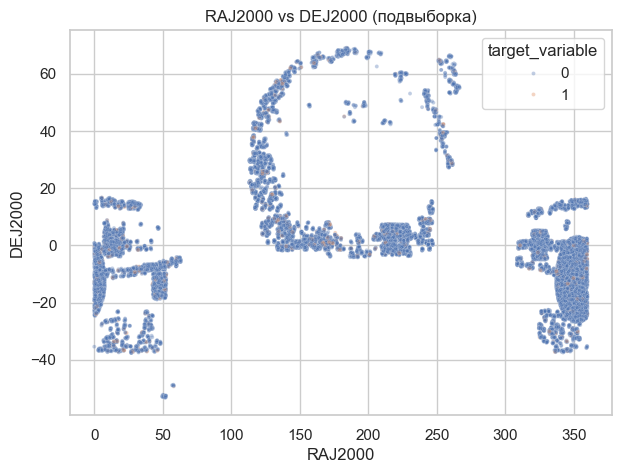

In [40]:
sky = df[['RAJ2000', 'DEJ2000', 'target_variable']].dropna().sample(min(30000, len(df)), random_state=42)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=sky, x='RAJ2000', y='DEJ2000', hue='target_variable', s=8, alpha=0.35)
plt.title('RAJ2000 vs DEJ2000 (подвыборка)')
plt.show()


## Предобработка и структура данных

На этом этапе выявляем основные «красные флаги» перед очисткой. Ключевой принцип: **все проблемные критерии применяются только к `target=0`**. Объекты, подтверждённые VSX (`target=1`), удалять нельзя даже при плохой APASS-фотометрии — их переменность уже верифицирована независимым каталогом.

- **Отсутствие координат** — такие строки не привязаны к позиции на небе.
- **Малый `nobs` (все объекты)** — фотометрия из единственного снимка не поддаётся усреднению.
- **Малый `nobs` для `target=0`** — если у объекта мало наблюдений и он не попал в VSX, мы не можем утверждать, что он действительно непеременный. Такие «ненадёжные отрицательные» зашумляют обучение.
- **Нулевые/отрицательные ошибки APASS для `target=0`** — физически невозможное значение. Для `target=1` не применяем: среди известных переменных много ярких звёзд, которые насыщают детектор APASS.

In [41]:
pre = df.copy()

summary = {
    'rows_total': int(len(pre)),
    'missing_coords': int(pre[['RAJ2000', 'DEJ2000']].isna().any(axis=1).sum()),
    'nobs_lt_2': int((pre['nobs'] < 2).sum()) if 'nobs' in pre.columns else np.nan,
}

if apass_err_cols:
    summary['rows_with_err_le_0'] = int((pre[apass_err_cols] <= 0).any(axis=1).sum())

display(pd.DataFrame([summary]))


,rows_total,missing_coords,nobs_lt_2,rows_with_err_le_0
0,847823,0,0,150403


Отдельно сравниваю пороги по `nobs`.


In [42]:
if 'nobs' in pre.columns:
    rows = []
    for thr in [2, 3, 5]:
        left = int((pre['nobs'] >= thr).sum())
        rows.append([thr, left, left / len(pre)])
    display(pd.DataFrame(rows, columns=['nobs_threshold', 'rows_left', 'fraction_left']))


,nobs_threshold,rows_left,fraction_left
0,2,847823,1.000000
1,3,847823,1.000000
2,5,467847,0.551822


Проверяю распределение служебных метрик качества,
которые у нас уже есть после недели 3.


In [16]:
qc_cols = [c for c in ['match_sep_arcsec', 'match_phot_chi2', 'quality_realistic'] if c in pre.columns]
if qc_cols:
    display(pre[qc_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)


,count,mean,std,min,50%,90%,95%,99%,max
match_sep_arcsec,62501.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
match_phot_chi2,58979.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
quality_realistic,847823.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


# Просмотр описательных статистик и основы стилизации таблиц

`describe()` — первая остановка при описательном анализе данных. В контексте нашей задачи она позволяет сразу:
- оценить **диапазоны звёздных величин** (min/max) и убедиться, что они физически разумны;
- найти **аномальные значения**: нули или отрицательные числа там, где их быть не должно (ошибки измерений);
- сравнить **масштабы разброса** (std) в разных диапазонах — оптика и UV ведут себя совершенно по-разному;
- увидеть, как **стандартное отклонение** соотносится со средним: высокое std относительно mean — сигнал о возможных выбросах или смешении разных типов объектов.

Стилизация таблицы — не косметика, а инструмент: функция `highlight_min` подсвечивает строки, где `min ≤ 0`. Взгляд сразу цепляется за проблемные столбцы, особенно в широких таблицах с десятками признаков.

Сначала — `describe` по всем числовым полям. Потом — подсветка строк, где `min ≤ 0`.

In [43]:
desc = pre.select_dtypes(include=['number']).describe().T

def highlight_min(row):
    if row['min'] <= 0:
        return ['background-color: #ff0000'] * len(row)
    return [''] * len(row)

display(desc.style.apply(highlight_min, axis=1))


,count,mean,std,min,25%,50%,75%,max
RAJ2000,847823.000000,219.169677,124.067672,0.000359,123.393945,231.016600,340.742734,359.999531
DEJ2000,847823.000000,1.485996,19.136906,-53.343111,-9.099712,-0.311560,6.246935,69.269047
nobs,847823.000000,8.614961,23.232699,3.000000,4.000000,5.000000,7.000000,387.000000
Vmag,847823.000000,14.610108,1.467368,5.980000,13.819000,14.918000,15.703000,17.838000
e_Vmag,847823.000000,0.055100,0.051585,0.000000,0.026000,0.045000,0.072000,3.078000
Bmag,847823.000000,15.388030,1.491412,6.341000,14.572000,15.699000,16.499000,19.174000
e_Bmag,847823.000000,0.065107,0.059138,0.000000,0.030000,0.052000,0.084000,3.036000
gpmag,841779.000000,14.961739,1.470286,6.563000,14.155000,15.270000,16.063000,18.632000
e_gpmag,841779.000000,0.051122,0.070332,0.000000,0.023000,0.037000,0.057000,3.579000
rpmag,840340.000000,14.378388,1.449779,5.607000,13.591000,14.673000,15.455000,18.618000


Для столбцов ошибок APASS — отдельный взгляд. Ошибка измерения (`e_Vmag`, `e_Bmag` и т.п.) обязана быть **строго положительной**: она отражает стандартное отклонение фотометрических наблюдений за несколько эпох. Нулевые значения — верный признак некорректных строк: либо звезда была слишком яркой для детектора (насыщение), либо поле заполнено нулём как заглушкой. Подсветка ячеек с `min ≤ 0` позволяет мгновенно увидеть, в каких диапазонах таких случаев больше.

In [44]:
if apass_err_cols:
    err_desc = pre[apass_err_cols].describe().T

    def red_if_nonpos(v):
        try:
            return 'background-color: #ff0000' if float(v) <= 0 else ''
        except Exception:
            return ''

    display(err_desc.style.map(red_if_nonpos, subset=['min']))


,count,mean,std,min,25%,50%,75%,max
e_Vmag,847823.000000,0.055100,0.051585,0.000000,0.026000,0.045000,0.072000,3.078000
e_Bmag,847823.000000,0.065107,0.059138,0.000000,0.030000,0.052000,0.084000,3.036000
e_gpmag,841779.000000,0.051122,0.070332,0.000000,0.023000,0.037000,0.057000,3.579000
e_rpmag,840340.000000,0.056002,0.059488,0.000000,0.028000,0.046000,0.071000,5.661000
e_ipmag,795796.000000,0.088316,0.100352,0.000000,0.036000,0.068000,0.110000,3.410000


# Чистим датасет от невалидных наблюдений

Все четыре критерия применяются **только к `target=0`** (кроме первых двух, которые технически универсальны, но фактически ничего не дают). Логика единая: объекты, подтверждённые VSX (`target=1`), уже верифицированы независимым каталогом — их качество измерений APASS вторично.

**1. Отсутствие координат** — строки без `RAJ2000`/`DEJ2000` не привязаны к небу.

**2. `nobs < 2` (все объекты)** — наблюдение из единственного снимка не даёт информации о повторяемости. Надёжная фотометрия начинается хотя бы с двух эпох.

**3. `nobs < 5` только для `target=0`** — с малым числом наблюдений мы просто не успели поймать переменность. Такой объект — ненадёжный отрицательный пример, который будет вводить модель в заблуждение. Для `target=1` (VSX) nobs не важен: переменность уже доказана.

**4. APASS-ошибка `≤ 0` только для `target=0`** — физически невозможное значение, типичный артефакт для очень ярких звёзд (насыщение детектора). Но среди известных переменных много именно ярких объектов (цефеиды, мириды, затменные), поэтому к `target=1` этот фильтр не применяем.

Каждый критерий фиксируется отдельной маской, итоговый `invalid_mask` — их объединение.

In [45]:
NOBS_MIN_NONVAR = 5  # для объектов без VSX-метки требуем не менее 5 наблюдений

invalid_coords = pre[['RAJ2000', 'DEJ2000']].isna().any(axis=1)
invalid_nobs = (pre['nobs'] < 2) if 'nobs' in pre.columns else pd.Series(False, index=pre.index)

# Строгий порог для непеременных: с малым nobs нельзя утверждать, что объект не переменный
invalid_nobs_nonvar = (
    (pre['nobs'] < NOBS_MIN_NONVAR) & (pre['target_variable'] == 0)
) if 'nobs' in pre.columns else pd.Series(False, index=pre.index)

# Нулевые/отрицательные ошибки — тоже только для target=0:
# подтверждённые переменные из VSX сохраняем даже если APASS их «засветил»
invalid_err = pd.Series(False, index=pre.index)
if apass_err_cols:
    invalid_err = (pre[apass_err_cols] <= 0).any(axis=1) & (pre['target_variable'] == 0)

invalid_mask = invalid_coords | invalid_nobs | invalid_err | invalid_nobs_nonvar

report = pd.DataFrame([
    ['Всего строк',                                  int(len(pre))],
    ['Плохие координаты',                            int(invalid_coords.sum())],
    ['nobs < 2 (все объекты)',                       int(invalid_nobs.sum())],
    [f'nobs < {NOBS_MIN_NONVAR} (только target=0)',  int(invalid_nobs_nonvar.sum())],
    ['APASS error <= 0 (только target=0)',           int(invalid_err.sum())],
    ['Удаляем всего (union)',                        int(invalid_mask.sum())],
], columns=['Проверка', 'Количество'])

display(report)

df_clean = pre.loc[~invalid_mask].copy()
print('После очистки:', df_clean.shape)
print('target=1 сохранено:', int(df_clean['target_variable'].sum()),
      '/', int(pre['target_variable'].sum()))

,Проверка,Количество
0,Всего строк,847823
1,Плохие координаты,0
2,nobs < 2 (все объекты),0
3,nobs < 5 (только target=0),369294
4,APASS error <= 0 (только target=0),147089
5,Удаляем всего (union),407366


После очистки: (440457, 37)
target=1 сохранено: 28127 / 28127


Проверяем, что фильтр действительно отработал.


In [46]:
print('Координаты NaN после очистки:', int(df_clean[['RAJ2000', 'DEJ2000']].isna().any(axis=1).sum()))

if 'nobs' in df_clean.columns:
    print('nobs < 2 после очистки:', int((df_clean['nobs'] < 2).sum()))
    nonvar_low_nobs = int(((df_clean['nobs'] < NOBS_MIN_NONVAR) & (df_clean['target_variable'] == 0)).sum())
    print(f'nobs < {NOBS_MIN_NONVAR} у target=0 после очистки:', nonvar_low_nobs)

if apass_err_cols:
    err_nonvar = int(((df_clean[apass_err_cols] <= 0).any(axis=1) & (df_clean['target_variable'] == 0)).sum())
    print('APASS error <= 0 у target=0 после очистки:', err_nonvar)

print('target=1 после очистки:', int(df_clean['target_variable'].sum()))

Координаты NaN после очистки: 0
nobs < 2 после очистки: 0
nobs < 5 у target=0 после очистки: 0
APASS error <= 0 у target=0 после очистки: 0
target=1 после очистки: 28127


# Что ещё можно вытянуть из данных?

После базовой очистки смотрим на структуру данных глубже: средние яркости по диапазонам, точность измерений и их относительная ошибка, выбросы, корреляции между каналами и покрытие разными телескопами. Всё это помогает понять, какие признаки несут информацию, а какие зашумлены или дублируют друг друга — что напрямую влияет на выбор признаков для последующего моделирования.

Средние значения звёздных величин по диапазонам показывают, насколько типичный объект в выборке ярок в каждой полосе. Важно помнить, что **шкала звёздных величин обратная**: чем меньше число, тем ярче объект.

Физически закономерно, что большинство звёзд выборки (они преимущественно холодные, типа G–K) ярче в красной части спектра (`ipmag`, `rpmag`) и значительно слабее в ультрафиолете (`nuv_mag`, особенно `fuv_mag`). Большой разрыв между оптическими и UV-диапазонами подтверждает корректность данных и отражает физическую природу наблюдаемых объектов.

In [48]:
mags = [c for c in ['Jmag', 'Hmag', 'Kmag', 'Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag', 'fuv_mag', 'nuv_mag'] if c in df_clean.columns]
display(df_clean[mags].mean().sort_values().to_frame('mean_mag'))

,mean_mag
Kmag,11.844669
Hmag,11.916874
Jmag,12.294579
ipmag,13.704407
rpmag,13.945288
Vmag,14.174465
gpmag,14.530215
Bmag,14.954588
nuv_mag,20.017763
fuv_mag,23.245263


Средние абсолютные ошибки по диапазонам показывают типичную точность фотометрии в каждом фильтре. Для APASS значения порядка 0,05–0,10 — норма.

Отношение `error / magnitude` — более информативная метрика: оно показывает **относительную точность**. Среднее значение ниже 1% означает высококачественные измерения. Но максимальные значения могут достигать 20–30%, что указывает на отдельные сильно зашумлённые строки. Обратите внимание на `e_ipmag`: в i-диапазоне ошибка систематически выше, что может быть связано с особенностями работы детектора в этой полосе — это стоит учитывать при построении признаков.

In [49]:
if apass_err_cols:
    display(df_clean[apass_err_cols].mean().to_frame('mean_error'))

    ratio_rows = []
    for m in ['Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag']:
        e = f'e_{m}'
        if m in df_clean.columns and e in df_clean.columns:
            ratio = df_clean[e] / df_clean[m].abs().replace(0, np.nan)
            ratio_rows.append([m, float(ratio.mean()), float(ratio.max())])

    display(pd.DataFrame(ratio_rows, columns=['mag', 'mean(err/mag)', 'max(err/mag)']))


,mean_error
e_Vmag,0.057013
e_Bmag,0.064061
e_gpmag,0.051070
e_rpmag,0.057326
e_ipmag,0.099878


,mag,mean(err/mag),max(err/mag)
0,Vmag,0.004003,0.296675
1,Bmag,0.004213,0.186417
2,gpmag,0.003535,0.268070
3,rpmag,0.004108,0.289393
4,ipmag,0.007266,0.209113


Анализ выбросов по двум классическим критериям: **правило 1,5 IQR** (не предполагает нормальности) и **правило 3σ** (основано на предположении нормального распределения).

Для оптических диапазонов число выбросов обычно невелико и сравнимо по обоим методам — признак достаточно симметричных распределений. Резкое расхождение между IQR- и 3σ-числами сигнализирует о **скошенном распределении с тяжёлым хвостом**.

Особое внимание — на **UV-диапазоны** (`fuv_mag`, `nuv_mag`): там выбросов по IQR значительно больше, чем по 3σ. Это типичная картина: многие звёзды не излучают в дальнем ультрафиолете вовсе или имеют сигнал ниже порога детектора — распределение оказывается сильно скошенным. Для таких признаков стандартные методы нормализации работают хуже, и к ним стоит подходить отдельно (логарифмирование, квантильное преобразование и т.п.).

In [24]:
out_rows = []
for m in mags:
    q1 = df_clean[m].quantile(0.25)
    q3 = df_clean[m].quantile(0.75)
    iqr = q3 - q1
    low_iqr, high_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = int(((df_clean[m] < low_iqr) | (df_clean[m] > high_iqr)).sum())

    mu, sd = df_clean[m].mean(), df_clean[m].std()
    low_3s, high_3s = mu - 3 * sd, mu + 3 * sd
    n_3s = int(((df_clean[m] < low_3s) | (df_clean[m] > high_3s)).sum())

    out_rows.append([m, n_iqr, n_3s])

display(pd.DataFrame(out_rows, columns=['column', 'outlier_iqr', 'outlier_3sigma']))


,column,outlier_iqr,outlier_3sigma
0,Vmag,4428,1877
1,Bmag,4358,1985
2,gpmag,3979,1767
3,rpmag,4286,2023
4,ipmag,3940,2238
5,fuv_mag,5448,2195
6,nuv_mag,4219,1244


Корреляционная матрица фотометрических каналов показывает степень линейной связи между измерениями яркости в разных диапазонах.

**Оптические фильтры** (`Vmag`, `Bmag`, `gpmag`, `rpmag`, `ipmag`) ожидаемо сильно коррелируют между собой: они измеряют соседние участки спектра, и для большинства звёзд яркость в них меняется согласованно. Высокая корреляция — подтверждение качества данных, а одновременно сигнал о **мультиколлинеарности** при построении линейных моделей. Такие признаки лучше преобразовывать в цветовые индексы (разности величин между фильтрами).

**UV-диапазоны** (`fuv_mag`, `nuv_mag`) показывают значительно более слабую корреляцию с оптикой. Ультрафиолетовое излучение чувствительно к температуре и активности звезды: горячие и активные объекты ярки в UV, холодные — практически не видны. Это делает UV-признаки **потенциально очень информативными** для задачи классификации переменных звёзд: многие переменные (особенно эруптивного и катаклизмического типов) активны именно в этом диапазоне.

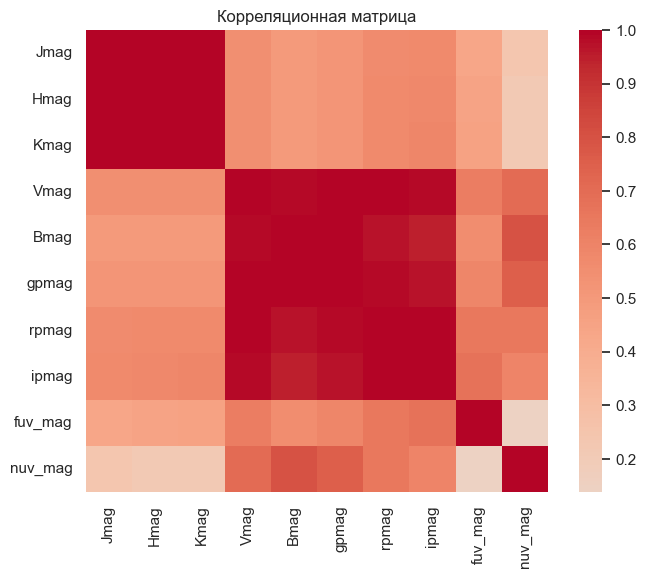

In [51]:
corr_cols = [c for c in ['Jmag', 'Hmag', 'Kmag', 'Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag', 'fuv_mag', 'nuv_mag'] if c in df_clean.columns]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')
plt.show()

Покрытие источников показывает, сколько объектов одновременно наблюдалось разными телескопами. `has_galex` — флаг наличия UV-данных (GALEX), `has_2mass` — ИК-данных (2MASS). Кросс-таблица даёт сразу несколько полезных сведений:

- **Размер групп**: большинство объектов покрыто только одним из телескопов или только APASS. Для объектов без реального измерения значения `fuv_mag`, `nuv_mag`, `Jmag`, `Hmag`, `Kmag` были заполнены импутацией — это отражается в флагах `fuv_flag` и т.д.
- **Доля переменных по группам** (`pct_variable`): если в одной группе переменных существенно больше — это значит, что признак покрытия сам по себе несёт предсказательную силу. Например, UV-покрытие чаще встречается у интересных (в том числе переменных) объектов, поскольку GALEX наблюдал преимущественно горячие и активные звёзды.

In [52]:
if {'has_galex', 'has_2mass'}.issubset(df_clean.columns):
    cov = pd.crosstab(df_clean['has_galex'], df_clean['has_2mass'], margins=True)
    display(cov)

    cov_target = pd.crosstab(
        [df_clean['has_galex'], df_clean['has_2mass']],
        df_clean['target_variable'],
        normalize='index'
    ) * 100
    cov_target = cov_target.rename(columns={0: 'pct_non_variable', 1: 'pct_variable'})
    display(cov_target)


has_2mass,0,1,All
has_galex,,,
0,0,108839,108839
1,286939,44679,331618
All,286939,153518,440457


target_variable      pct_non_variable  pct_variable
has_galex has_2mass                                
0         1                 95.343581      4.656419
1         0                 92.516179      7.483821
          1                 96.452472      3.547528

Сохраняю финальный файл недели после очистки.


In [53]:
ordered_cols = [
    'RAJ2000', 'DEJ2000', 'nobs',
    'Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag',
    'e_Vmag', 'e_Bmag', 'e_gpmag', 'e_rpmag', 'e_ipmag',
    'fuv_mag', 'nuv_mag', 'Jmag', 'Hmag', 'Kmag',
    'fuv_flag', 'nuv_flag', 'J_flag', 'H_flag', 'K_flag',
    'has_galex', 'has_2mass',
    'match_sep_arcsec', 'match_phot_chi2', 'quality_realistic',
    'vsx_present', 'vsx_type', 'vsx_period', 'vsx_min_mag', 'vsx_max_mag', 'vsx_amplitude', 'vsx_name', 'vsx_sep_arcsec',
    'target_variable',
]

cols = [c for c in ordered_cols if c in df_clean.columns]
final_df = df_clean[cols].copy()

final_df.to_csv(OUTPUT_PATH, index=False)

print('Saved:', OUTPUT_PATH)
print('final shape:', final_df.shape)

Saved: w4_labeled_dataset.csv
final shape: (440457, 37)


## Что в итоге получилось

- VSX добавлен и привязан к базовой таблице.
- `target_variable` сформирован.
- Анализ и очистка выполнены уже на объединенном наборе.
- Итог сохранен в `w4_labeled_dataset.csv`.
